In [0]:
appointments_data = [
(1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
(1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
(1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
(1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
(1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
(1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
(1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
(1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
(1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
(1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
(1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
(1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
(1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
(1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
(1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]

columns = [
    "appointment_id",
    "city",
    "department",
    "hospital",
    "consultation_fee",
    "status"
]

df = spark.createDataFrame(appointments_data, columns)

display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


In [0]:
city_count = df.groupBy("city").count()
display(city_count)

city,count
Hyderabad,3
Bangalore,3
Mumbai,3
Delhi,3
Chennai,3


Databricks visualization. Run in Databricks to view.

In [0]:
dept_count = df.groupBy("department").count()
display(dept_count)

department,count
Cardiology,4
Neurology,3
Dermatology,3
Orthopedics,2
Pediatrics,3


Databricks visualization. Run in Databricks to view.

In [0]:
status_count = df.groupBy("status").count()
display(status_count)

status,count
Completed,10
Pending,3
Cancelled,2


Databricks visualization. Run in Databricks to view.

In [0]:
city_revenue = df.groupBy("city") \
    .sum("consultation_fee") \
    .withColumnRenamed("sum(consultation_fee)", "revenue")

display(city_revenue)

city,revenue
Hyderabad,5600
Bangalore,6400
Mumbai,4800
Delhi,8000
Chennai,4550


Databricks visualization. Run in Databricks to view.

In [0]:
dept_revenue = df.groupBy("department") \
    .sum("consultation_fee") \
    .withColumnRenamed("sum(consultation_fee)", "revenue")

display(dept_revenue)

department,revenue
Cardiology,10500
Neurology,7500
Dermatology,2850
Orthopedics,4900
Pediatrics,3600


Databricks visualization. Run in Databricks to view.

In [0]:
hospital_revenue = df.groupBy("hospital") \
    .sum("consultation_fee") \
    .withColumnRenamed("sum(consultation_fee)", "revenue")

display(hospital_revenue)

hospital,revenue
Apollo,7500
Yashoda,6300
Care,7250
Max,8300


Databricks visualization. Run in Databricks to view.

In [0]:
display(
    df.select("appointment_id","consultation_fee")
)

appointment_id,consultation_fee
1001,1500
1002,2200
1003,900
1004,2500
1005,1200
1006,3000
1007,1000
1008,2600
1009,2800
1010,2400


Databricks visualization. Run in Databricks to view.

In [0]:
fee_trend = df.orderBy("appointment_id")

display(fee_trend.select("appointment_id","consultation_fee"))

appointment_id,consultation_fee
1001,1500
1002,2200
1003,900
1004,2500
1005,1200
1006,3000
1007,1000
1008,2600
1009,2800
1010,2400


Databricks visualization. Run in Databricks to view.

In [0]:
from pyspark.sql.functions import *
completed_df = df.filter(col("status") == "Completed")

display(completed_df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1004,Delhi,Orthopedics,Max,2500,Completed
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed
1011,Hyderabad,Pediatrics,Apollo,1100,Completed
1012,Bangalore,Cardiology,Max,3200,Completed
1014,Delhi,Neurology,Apollo,2700,Completed


In [0]:
completed_revenue = completed_df.groupBy("city") \
    .sum("consultation_fee") \
    .withColumnRenamed("sum(consultation_fee)", "revenue")

display(completed_revenue)

city,revenue
Hyderabad,5600
Bangalore,6400
Delhi,8000
Chennai,2400


Databricks visualization. Run in Databricks to view.

In [0]:
active_df = df.filter(col("status") != "Cancelled")

revenue_active = active_df.groupBy("city") \
    .sum("consultation_fee") \
    .withColumnRenamed("sum(consultation_fee)", "revenue")

display(revenue_active)

city,revenue
Hyderabad,5600
Bangalore,6400
Mumbai,3500
Delhi,8000
Chennai,3350


Databricks visualization. Run in Databricks to view.

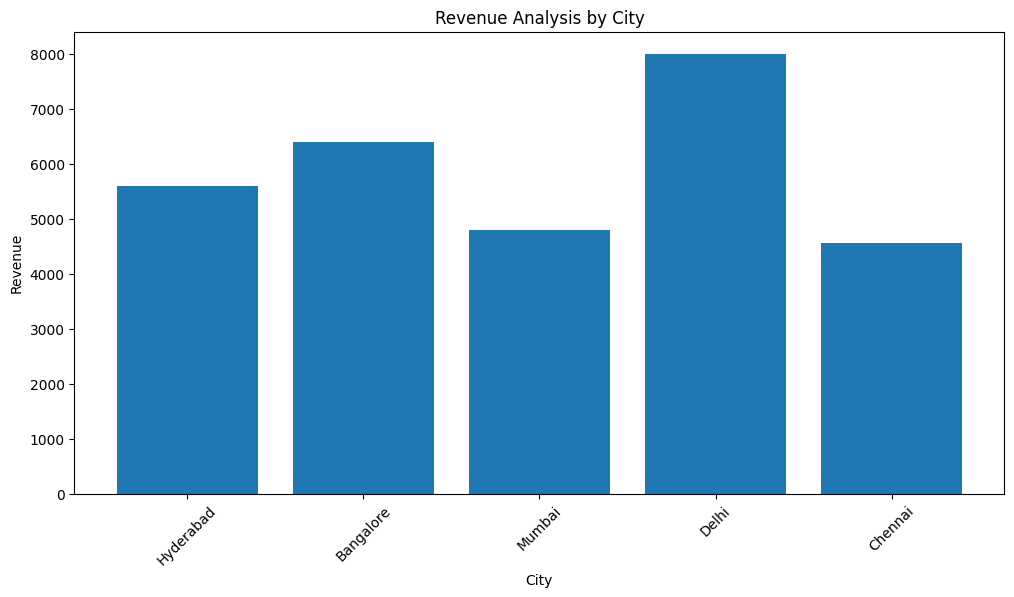

In [0]:
import matplotlib.pyplot as plt

pdf = city_revenue.toPandas()

plt.figure(figsize=(12,6))
plt.bar(pdf["city"], pdf["revenue"])
plt.title("Revenue Analysis by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [0]:
top3_cities = city_revenue.orderBy(
    col("revenue").desc()
).limit(3)

display(top3_cities)

city,revenue
Delhi,8000
Bangalore,6400
Hyderabad,5600


Databricks visualization. Run in Databricks to view.

In [0]:
top3_departments = dept_revenue.orderBy(
    col("revenue").desc()
).limit(3)
display(top3_departments)

department,revenue
Cardiology,10500
Neurology,7500
Orthopedics,4900


Databricks visualization. Run in Databricks to view.

In [0]:
lowest_hospital = hospital_revenue.orderBy(
    col("revenue").asc()
).limit(1)

display(lowest_hospital)

hospital,revenue
Yashoda,6300


Databricks visualization. Run in Databricks to view.

In [0]:
hospital_share = df.groupBy("hospital").count()

display(hospital_share)

hospital,count
Apollo,5
Yashoda,3
Care,4
Max,3


Databricks visualization. Run in Databricks to view.

In [0]:
display(city_revenue)

city,revenue
Hyderabad,5600
Bangalore,6400
Mumbai,4800
Delhi,8000
Chennai,4550


Databricks visualization. Run in Databricks to view.

In [0]:
display(dept_revenue)

department,revenue
Cardiology,10500
Neurology,7500
Dermatology,2850
Orthopedics,4900
Pediatrics,3600


Databricks visualization. Run in Databricks to view.

In [0]:
display(status_count)

status,count
Completed,10
Pending,3
Cancelled,2


Databricks visualization. Run in Databricks to view.

In [0]:
display(hospital_revenue)

hospital,revenue
Apollo,7500
Yashoda,6300
Care,7250
Max,8300


Databricks visualization. Run in Databricks to view.

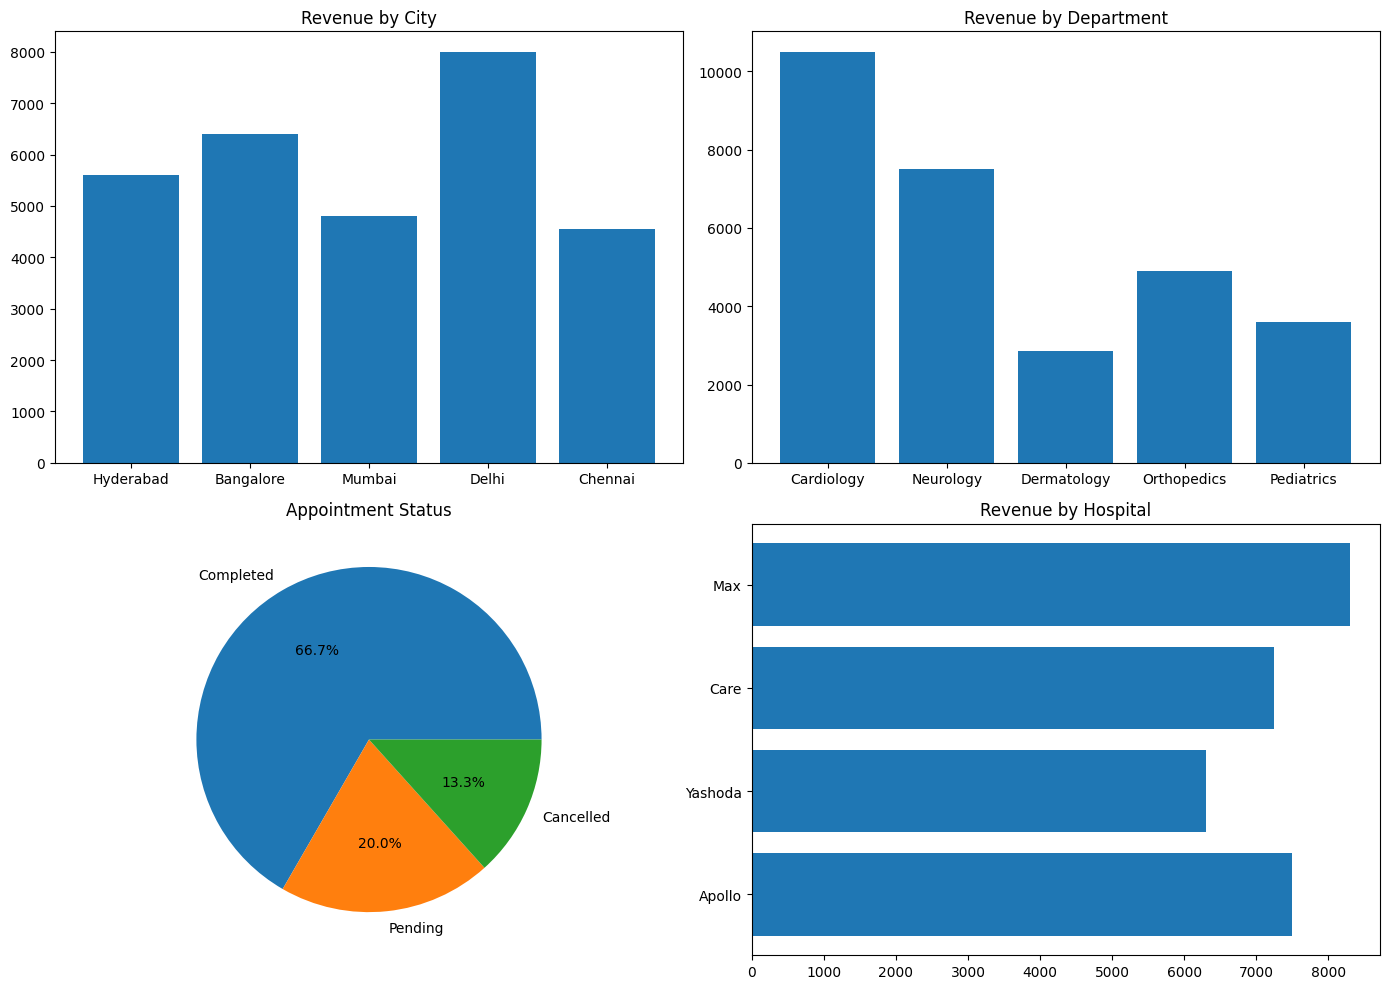

In [0]:
import matplotlib.pyplot as plt

city_pdf = city_revenue.toPandas()
dept_pdf = dept_revenue.toPandas()
status_pdf = status_count.toPandas()
hospital_pdf = hospital_revenue.toPandas()

fig, axs = plt.subplots(2,2, figsize=(14,10))

# City Revenue
axs[0,0].bar(city_pdf["city"], city_pdf["revenue"])
axs[0,0].set_title("Revenue by City")

# Department Revenue
axs[0,1].bar(dept_pdf["department"], dept_pdf["revenue"])
axs[0,1].set_title("Revenue by Department")

# Status Pie
axs[1,0].pie(
    status_pdf["count"],
    labels=status_pdf["status"],
    autopct="%1.1f%%"
)
axs[1,0].set_title("Appointment Status")

# Hospital Revenue
axs[1,1].barh(
    hospital_pdf["hospital"],
    hospital_pdf["revenue"]
)
axs[1,1].set_title("Revenue by Hospital")

plt.tight_layout()
plt.show()